<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit8/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv


!pip install pymc-bart
import pymc_bart as pmb


# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

Decision trees are flowcharts that contain inteerconnected nodes. Each node of a heirarchy has some relation to a parent node above. These nodes are predictors for the nodes below them. In some types of trees, the predictor nodes are sorted into predicted values, which help specify the likelihood of another "event" occuring.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

An incorrect tree depth can lead to an overfit model. Since more depth of the tree means there are more layers and therefore more predictors--this directly leads to a more overfit model. The issue with a single tree is that they are extremely vulnerable to overfitting. The model would memorize the data and fail to draw any trends from the dataset.

**Task4:**

How are BART models similar and different from a decision tree?

A BART model is effectively a more complex decision tree. Using a simiar tree structure, BART models use multiple decision trees to help model data. BART is essentially a decision tree on steroids, since it has processes in place to help prevent overfitting (regularization prior). They are most similar because they can both be directly applied to regressions.

Something unique about BART is that it's a combination of a bunch of smaller trees. This is a smart design choice because having trees of a smaller depth leads to less overfitting.

**Task5**:

Why would we use a BART model instead of a decision tree?

Since the whole idea behind BART is meant to be stable, BART models shine because of their ability to not overfit/underfit data, and capture nonlinear trends. Decision trees seem to lack these complexities, which is why BART is a better choice. However, BART is slower than decision tree models because of it's high attention to accuracy. BART is very fast compared to a lot of other models we've taken a look at, but is still slower than the traditional decision tree.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [2]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()
penguins.head()

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.75,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.80,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.25,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.45,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.65,male,2007


In [10]:
peng = penguins.dropna()

In [12]:
X = peng[["flipper_length", "bill_depth", "bill_length"]]
Y = peng["body_mass"].to_numpy()

In [ ]:
with pm.Model() as penguinModel:
    s = pm.HalfNormal('s', 6)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Normal("y", mu=μ, sigma=s, observed=Y)
    idata_penguin = pm.sample(compute_convergence_checks=False)

Output()

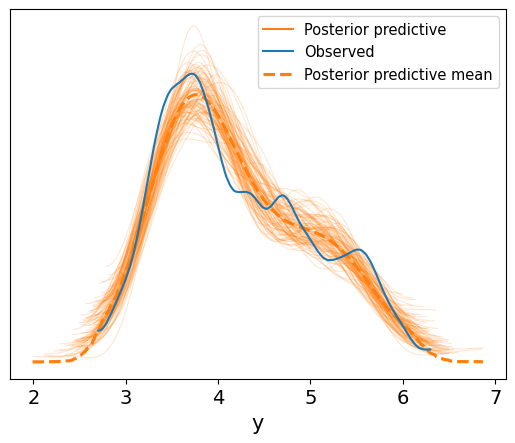

In [17]:
pm.sample_posterior_predictive(idata_penguin,penguinModel, extend_inferencedata=True)
ax = az.plot_ppc(idata_penguin, num_pp_samples=100, colors=["C1", "C0", "C1"])

This BART model seems to be performing pretty well! The ppc fits the data very well, matching the skewness and peaks with precision.

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

<Axes: xlabel='flipper_length', ylabel='body_mass'>

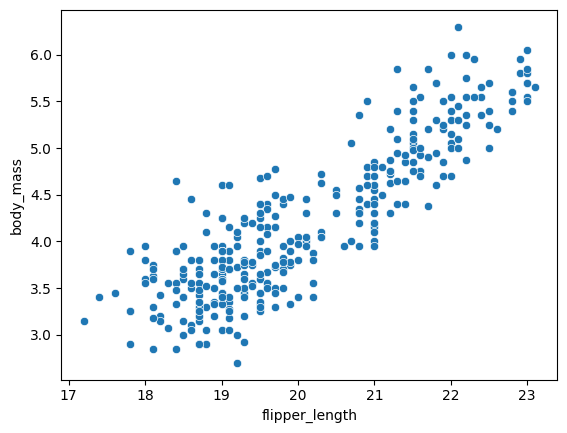

In [20]:
sns.scatterplot(peng, y = 'body_mass', x = 'flipper_length')

In [21]:
posterior_mean = idata_penguin.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguin, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguin, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


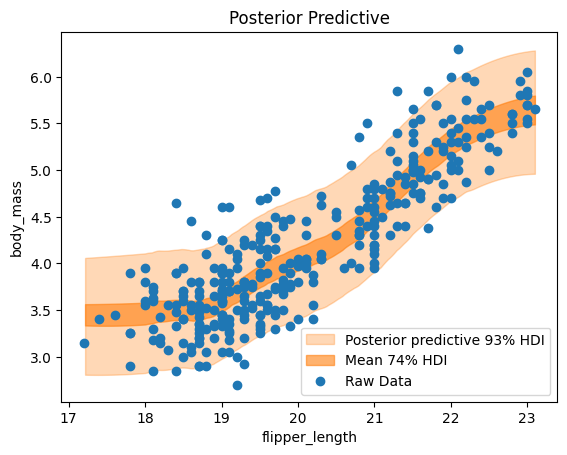

In [22]:
idx = np.argsort(X.to_numpy()[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive 93% HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean 74% HDI"},
)
ax.plot(peng['flipper_length'], peng["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

I think the plot I made above captures some important trends within the data, but I feel as if it doesn't capture the true association between flipper length and body mass. The reason behind this is because the data itself looks as if there is a linear trend. On top of this, it would make logical sense that as flipper length increased, body mass would too. However, since the model indicates that there could be a non linear trend, and I'm making this assumption based on the mean HDI path. My theory is that because there is a large cluster of data near a flipper length of 19, it gives those points more influence over the models fit. However, this may not be the case because there could have been issues with the data collection, since penguins with a longer flipper may have been harder to find.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

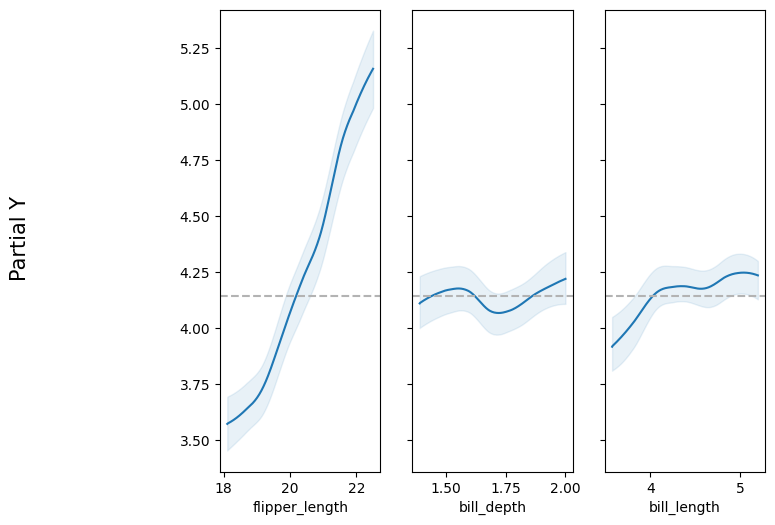

In [23]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

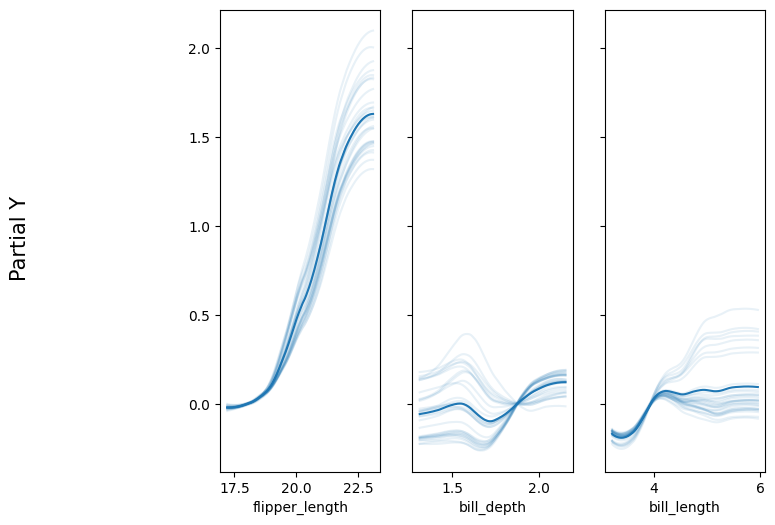

In [24]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

<Axes: ylabel='R²'>

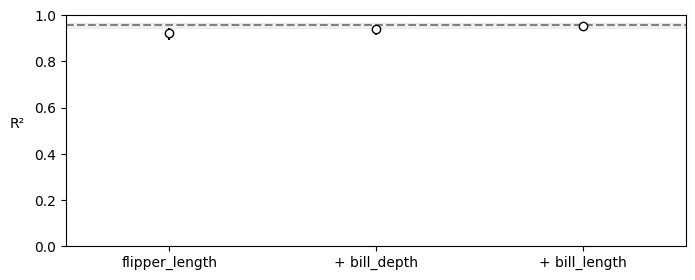

In [25]:
vi_penguins = pmb.compute_variable_importance(idata_penguin, μ_, X)
pmb.plot_variable_importance(vi_penguins)

Wow! bambi really does everything...

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Looking at the partial dependence plot, we see that flipper_length has an increasing roughly linear relationship. I criticized the "roughness" in a previous task, but compared to the other two relevant variables, it seems like an excellent and good predictor.

On the variable importance plot, we see that the coefficient of determination for a model with flipper length is around 0.94, which speaks volumes on how relevant of a variable it is to predict body mass. Now while including bill_depth and bill_length technically increase the $R^2$, this may be the case due to overfitting the model with more data. In general, an $R^2$ of 0.94 is exceptional. Looking at both the ice and pdp plots, bill_depth and bill_length are both non linear and don't seem to have a reasonable trend. Including them in an interaction would either be cheating (because of overfitting) or would not make a good model.